In [1]:
#importing the data set


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/NewspaperData.csv')
df.head(5)

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  34 non-null     object 
 1   daily      34 non-null     float64
 2   sunday     34 non-null     float64
dtypes: float64(2), object(1)
memory usage: 948.0+ bytes


In [5]:
#Corelation

In [7]:
df.corr(numeric_only = True)

,daily,sunday
daily,1.000000,0.958154
sunday,0.958154,1.000000


/var/folders/7b/rp_b1btd04154v527_55nf140000gn/T/ipykernel_81712/2796133955.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['daily'])


<Axes: xlabel='daily', ylabel='Density'>

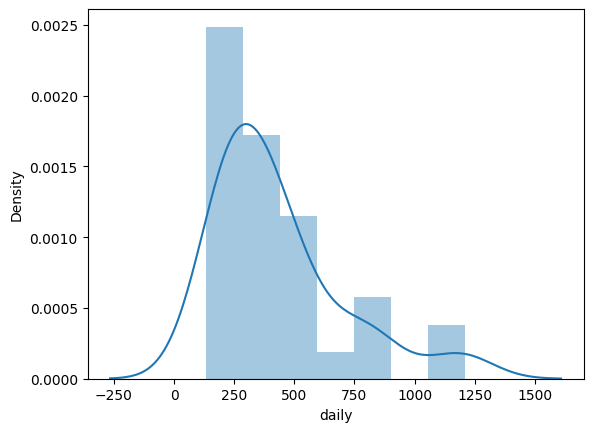

In [10]:
import seaborn as sns
sns.distplot(df['daily'])

/var/folders/7b/rp_b1btd04154v527_55nf140000gn/T/ipykernel_81712/1036117173.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sunday'])


<Axes: xlabel='sunday', ylabel='Density'>

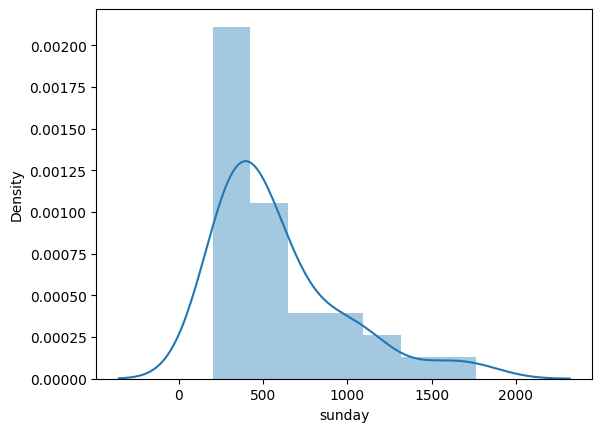

In [11]:
sns.distplot(df['sunday'])

In [12]:
# fitting a linear regression model



In [14]:
import statsmodels.formula.api as smf
model = smf.ols("sunday~daily" , data = df).fit()

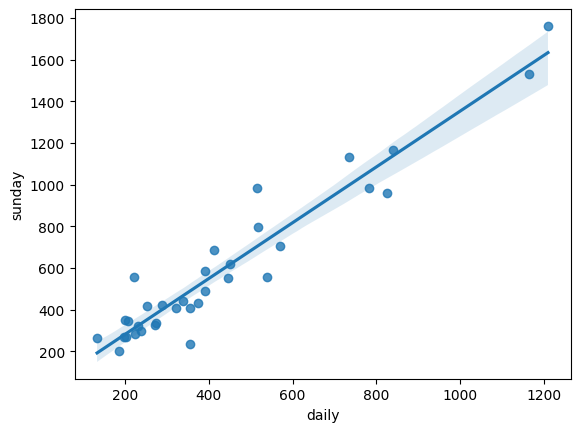

In [15]:
sns.regplot(x = 'daily' , y = 'sunday' , data = df);

In [19]:
# coefficent
model.params
# ans like  c 
# beta not  m
# beta one coffecients c and m of line y = mx + c 

Intercept    13.835630
daily         1.339715
dtype: float64

In [20]:
# t and p-values
print(model.tvalues, '\n' , model.pvalues)

Intercept     0.386427
daily        18.934840
dtype: float64 
 Intercept    7.017382e-01
daily        6.016802e-19
dtype: float64


In [21]:
# R squared vlaues
(model.rsquared,model.rsquared_adj)

(np.float64(0.9180596895873295), np.float64(0.9154990548869336))

In [22]:
# predict for the new data point



In [24]:
# predict for 200 and 300 daily circulations
newdata = pd.Series([200,300])

In [25]:
newdata

0    200
1    300
dtype: int64

In [27]:
data_pred = pd.DataFrame(newdata,columns=['daily'])

In [28]:
data_pred

,daily
0,200
1,300


In [29]:
model.predict(data_pred)

0    281.778581
1    415.750057
dtype: float64